# Training report cumulative reward

In [2]:
from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

REPORT_PATH = Path("eval") / "cmr_export"

def reports_from_file(path: Path) -> list[dict]:
    with path.open("r", encoding="utf-8") as file:
        payload = json.load(file)
    reports = payload.get("reports")
    if isinstance(reports, list):
        return [item for item in reports if isinstance(item, dict)]
    return [payload]

def generate_df_rows(paths: list[Path], names: list[str]) -> list[dict]:
    rows = []
    for path,name in zip(paths, names):
        for run_index, report in enumerate(reports_from_file(path), start=1):
            label = report.get("target_label") or report.get("target_checkpoint_id") or f"Run {run_index}"
            for episode, cumulative_reward in report.get("cumulative_reward_points", []):
                rows.append({
                    "file": name,
                    "run": label,
                    "episode": int(episode),
                    "cumulative_reward": float(cumulative_reward),
                })
    return rows



In [3]:
sns.set_theme(style="whitegrid")

def plot_cumulative_reward(paths: list[Path], names: list[str]):
    rows = generate_df_rows(paths, names)
    df = pd.DataFrame(rows, columns=["file", "run", "episode", "cumulative_reward"])
    df.head()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(
        data=df,
        x="episode",
        y="cumulative_reward",
        hue="file",
        estimator="mean",
        errorbar="sd",
        linewidth=2.2,
        ax=ax,
    )
    ax.set_title("Average cumulative reward by exported report file")
    ax.set_xlabel("Training episode")
    ax.set_ylabel("Cumulative reward")
    ax.legend(title="Report")
    plt.tight_layout()

## Task 1

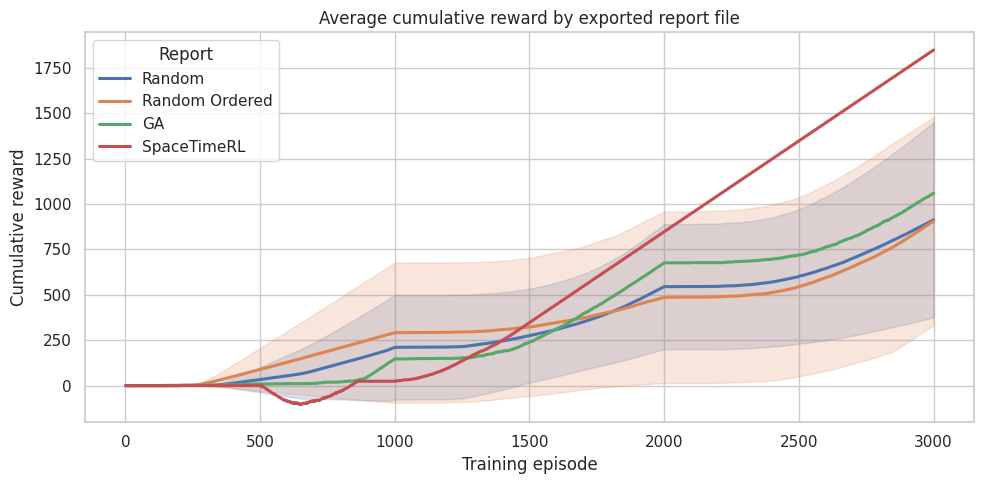

In [4]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task1"/ "random.json",
        REPORT_PATH / "task1"/ "random_ordered.json",
        REPORT_PATH / "task1"/ "ga.json",
        REPORT_PATH / "task1"/ "spacetimerl_jb.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"])

## Task 2

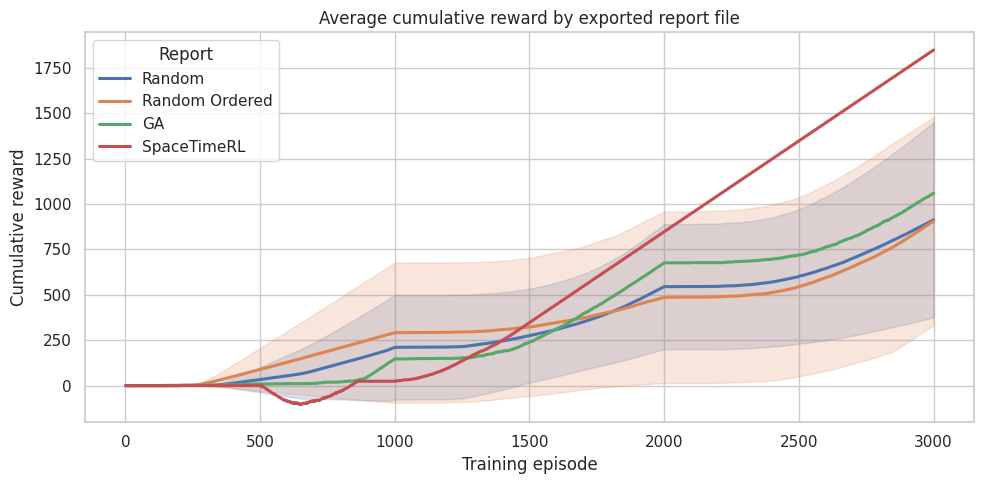

In [ ]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task2"/ "random.json",
        REPORT_PATH / "task2"/ "random_ordered.json",
        REPORT_PATH / "task2"/ "ga.json",
        REPORT_PATH / "task2"/ "spacetimerl_jb.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"])

## Task 3

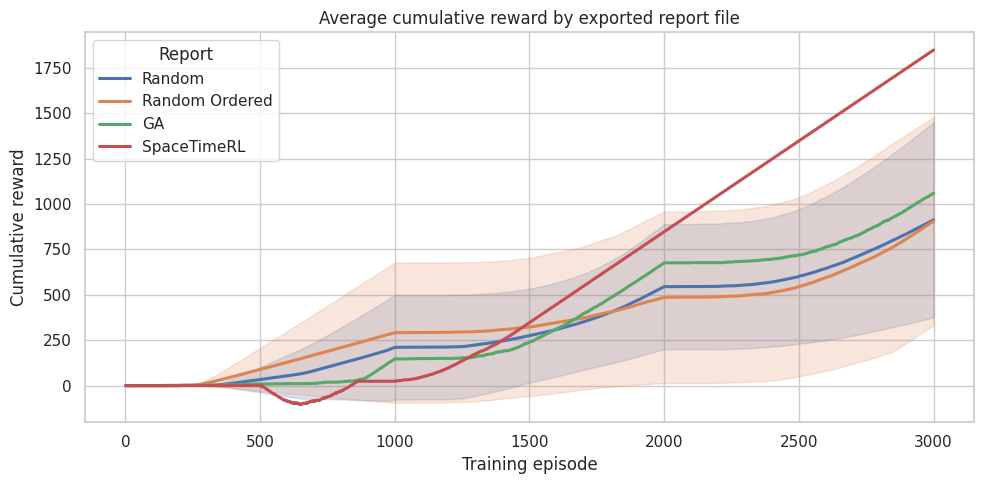

In [ ]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task3"/ "random.json",
        REPORT_PATH / "task3"/ "random_ordered.json",
        REPORT_PATH / "task3"/ "ga.json",
        REPORT_PATH / "task3"/ "spacetimerl_jb.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"])

## Task 1

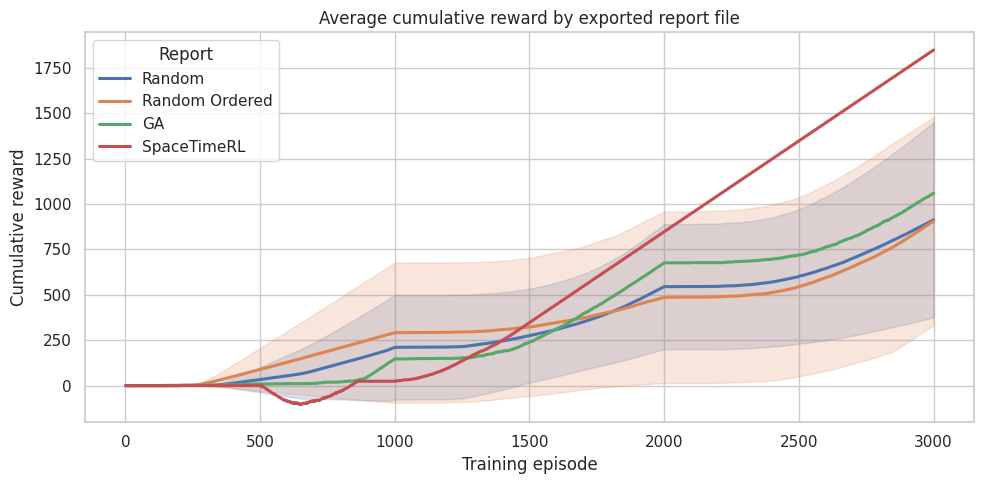

In [ ]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task1"/ "random.json",
        REPORT_PATH / "task1"/ "random_ordered.json",
        REPORT_PATH / "task1"/ "ga.json",
        REPORT_PATH / "task1"/ "spacetimerl_jb.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"])